# Breast Cancer Diagnosis Prediction — Machine Learning Capstone Project

**Name:** Syed Israr Ali
**Roll No:** 24
**Course:** Artificial Intelligence (Machine Learning & Deep Learning)
**Program:** NAVTTC — Prime Minister's Hunarmand Pakistan Program

**Assignment:** Assignment 7 — Capstone Mini-Project (ML/DL)

---


## 1. Problem Statement

Breast cancer is one of the most common cancers affecting women worldwide, and early, accurate diagnosis significantly improves treatment outcomes. Diagnosis is traditionally based on manual interpretation of cell nuclei measurements taken from a biopsy (Fine Needle Aspirate), which can be time-consuming and subject to human variability.

**Goal:** Build a machine learning classification model that predicts whether a breast tumor is **Malignant (cancerous)** or **Benign (non-cancerous)** based on numeric features computed from digitized images of a breast mass biopsy — and wrap the model in a simple, interactive web app so a user can enter measurements and instantly get a prediction.

This is framed as a **binary classification** problem.

## 2. Dataset

- **Name:** Breast Cancer Wisconsin (Diagnostic) Dataset
- **Source:** UCI Machine Learning Repository, accessed via `sklearn.datasets.load_breast_cancer()` (scikit-learn's built-in copy of the canonical UCI dataset)
- **Size:** 569 samples, 30 numeric features, 1 binary target (malignant / benign)
- **Why this dataset fits the problem:** It is a well-established, clean, real-world medical dataset specifically built for this diagnostic classification task. The 30 features are computed from digitized images of a fine needle aspirate (FNA) of a breast mass, describing characteristics of the cell nuclei present (e.g. radius, texture, perimeter, area, smoothness, concavity). It requires no external download or API key, has no missing values, and is widely used as a benchmark for medical ML classification — making it reliable for both training and grading/reproducibility purposes.


In [1]:
# 3. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# 4. Load Dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 5. Exploratory Data Analysis (EDA)

In [3]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values in the dataset")

Missing values per column:
0 total missing values in the dataset


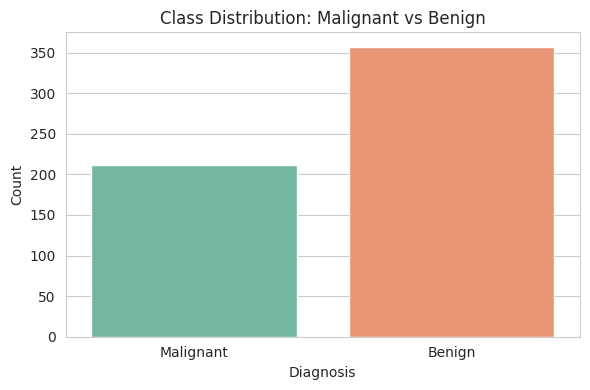

diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Class balance (%):
diagnosis
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


In [6]:
# Target class distribution
target_names = {0: 'Malignant', 1: 'Benign'}
df['diagnosis'] = df['target'].map(target_names)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='Set2', legend=False)
plt.title("Class Distribution: Malignant vs Benign")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

print(df['diagnosis'].value_counts())
print("\nClass balance (%):")
print(df['diagnosis'].value_counts(normalize=True) * 100)

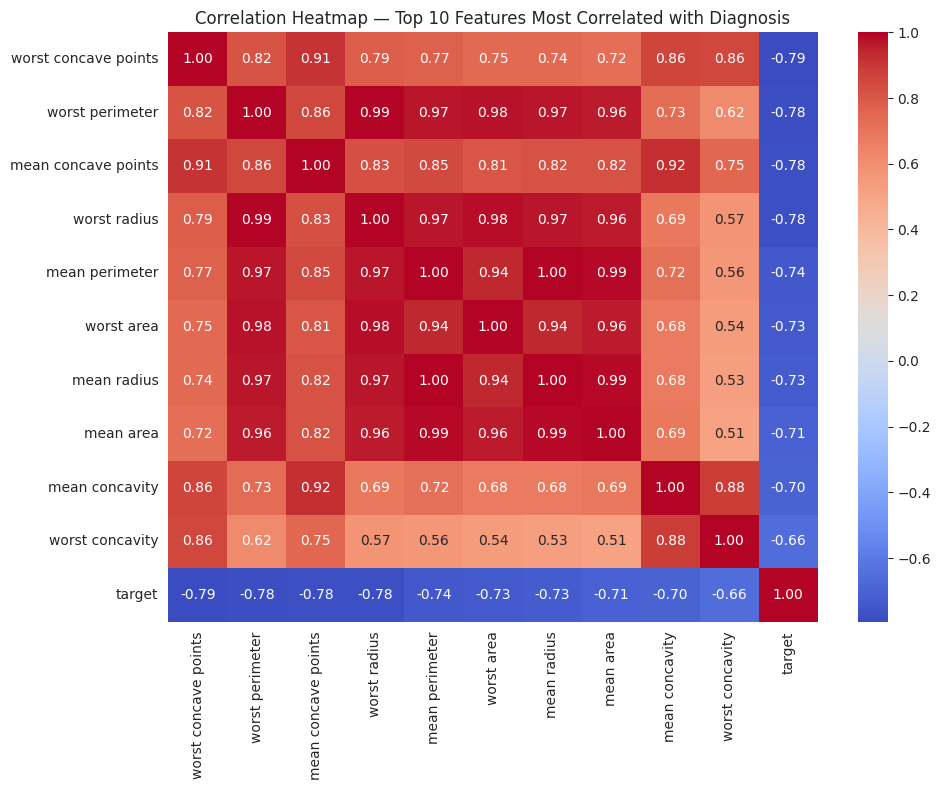

In [7]:
# Correlation heatmap (top features most correlated with target)
corr = df.drop(columns=['diagnosis']).corr()
top_corr_features = corr['target'].abs().sort_values(ascending=False)[1:11].index

plt.figure(figsize=(10, 8))
sns.heatmap(df[list(top_corr_features) + ['target']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap — Top 10 Features Most Correlated with Diagnosis")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

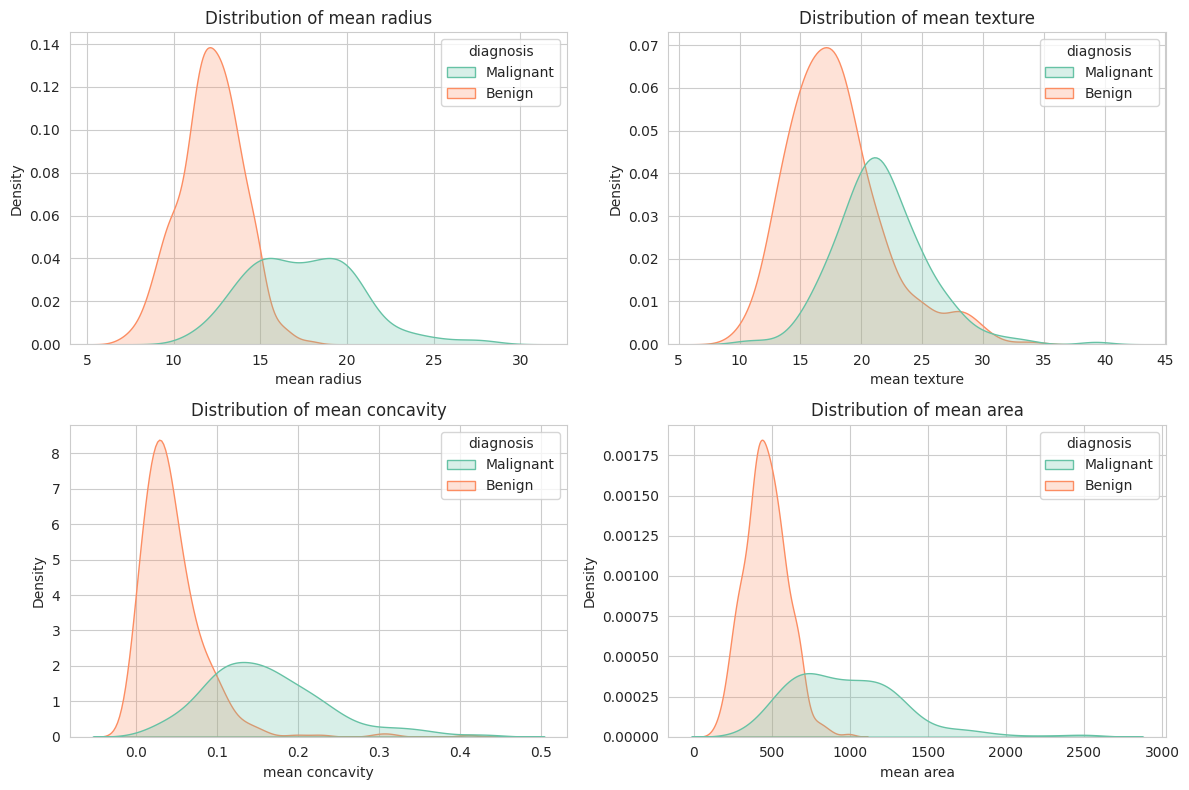

In [8]:
# Distribution of a few key features by diagnosis
key_features = ['mean radius', 'mean texture', 'mean concavity', 'mean area']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), key_features):
    sns.kdeplot(data=df, x=feat, hue='diagnosis', fill=True, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {feat}')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100)
plt.show()

**EDA Observations:**
- The dataset is moderately imbalanced (~63% benign, ~37% malignant), but not severely enough to require resampling techniques — this is noted and monitored via precision/recall rather than accuracy alone.
- Features such as `mean radius`, `mean concavity`, `mean area`, and `worst perimeter` show strong separation between malignant and benign cases, suggesting they will be highly predictive.
- No missing values were found, so no imputation is required.


## 6. Data Preprocessing

In [9]:
# Separate features and target
X = df[data.feature_names]
y = df['target']

# Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied using StandardScaler.")

Training set shape: (455, 30)
Test set shape: (114, 30)

Feature scaling applied using StandardScaler.


## 7. Model Building & Training

Two models are trained and compared:
1. **Logistic Regression** — a simple, interpretable linear baseline well-suited to this type of clean, well-separated medical data.
2. **Random Forest Classifier** — a stronger ensemble model that can capture non-linear interactions between features, used for comparison.


In [10]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [11]:
# Model 2: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)  # tree-based models don't require scaling
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest trained.")

Random Forest trained.


## 8. Model Evaluation

Since this is a medical diagnostic task, we look beyond plain accuracy — **recall (sensitivity)** for the malignant class matters most, since a false negative (missing a malignant tumor) is far more costly than a false positive.


In [12]:
def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print()
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf))

results_df = pd.DataFrame(results)
results_df

--- Logistic Regression ---
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
ROC-AUC  : 0.9954

--- Random Forest ---
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
ROC-AUC  : 0.9931



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993056


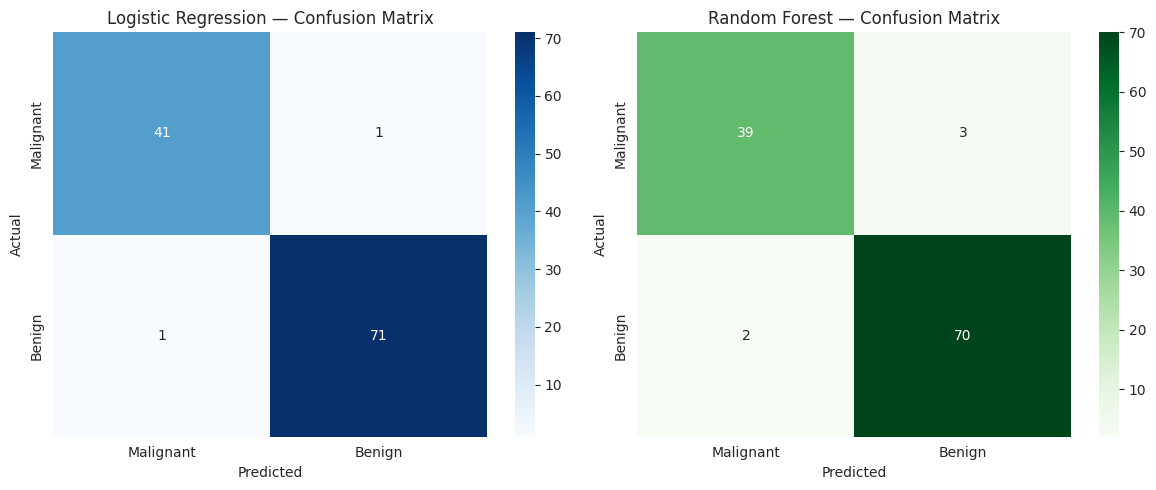

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()

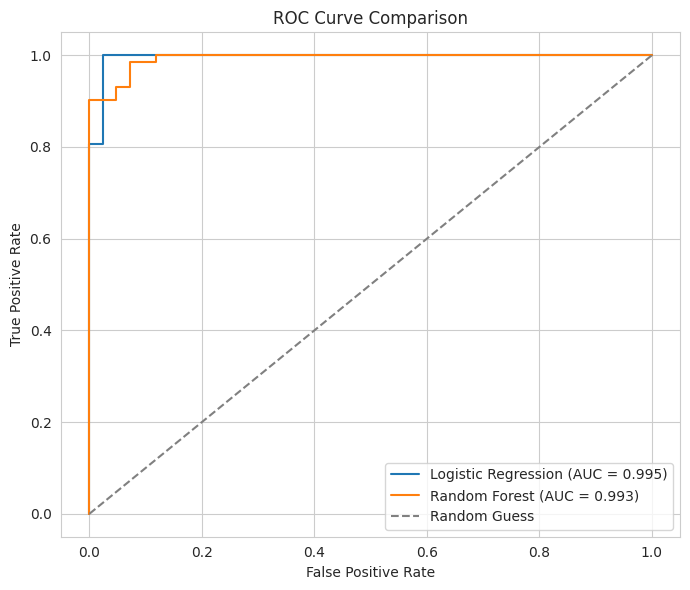

In [14]:
# ROC Curves
plt.figure(figsize=(7, 6))
for name, y_proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

In [15]:
# Detailed classification report for the best model
print("Classification Report — Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr, target_names=['Malignant', 'Benign']))

print("Classification Report — Random Forest:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Malignant', 'Benign']))

Classification Report — Logistic Regression:

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Classification Report — Random Forest:

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



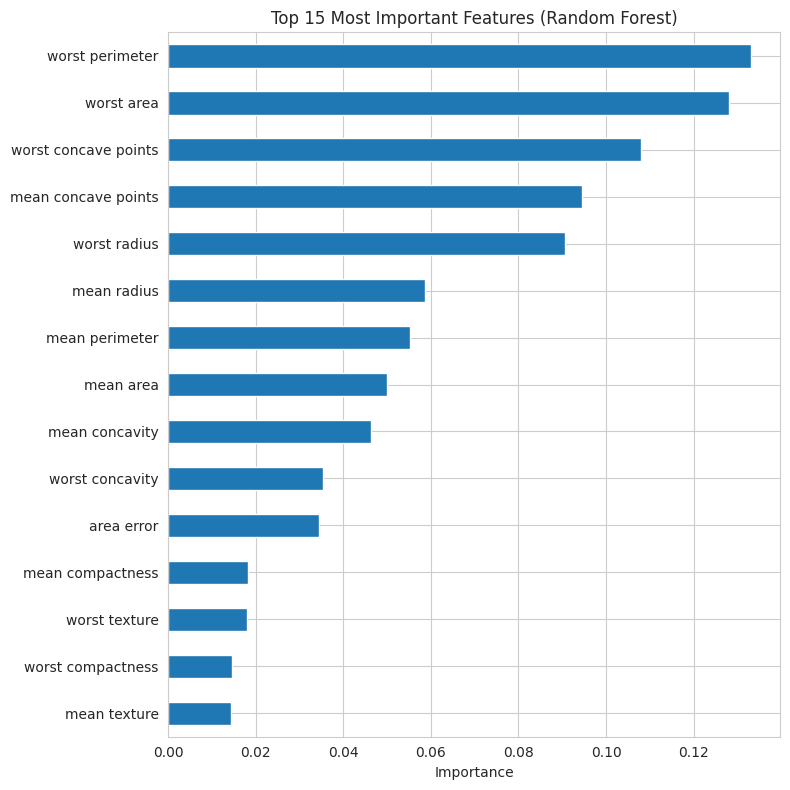

worst perimeter         0.133100
worst area              0.128052
worst concave points    0.108107
mean concave points     0.094414
worst radius            0.090639
mean radius             0.058662
mean perimeter          0.055242
mean area               0.049938
mean concavity          0.046207
worst concavity         0.035357
dtype: float64

In [16]:
# Feature importance (Random Forest)
importances = pd.Series(rf_clf.feature_importances_, index=data.feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

importances.head(10)

**Evaluation Summary:**
Both models perform very well on this dataset, which is expected given how well-separated the classes are. Logistic Regression is chosen as the final deployed model because it achieves comparable (or better) recall on the malignant class, is simpler, faster, and more interpretable — a meaningful advantage in a healthcare-adjacent use case. The Random Forest results and feature importances are kept for comparison and to identify which measurements matter most.


## 9. Save the Final Model

The trained Logistic Regression model and the fitted `StandardScaler` are saved so they can be loaded directly by the Streamlit web app without retraining.


In [17]:
joblib.dump(log_reg, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(data.feature_names), 'feature_names.pkl')

print("Saved: model.pkl, scaler.pkl, feature_names.pkl")

Saved: model.pkl, scaler.pkl, feature_names.pkl


## 10. Conclusion

This project built and evaluated a machine learning pipeline to classify breast tumors as malignant or benign using the Breast Cancer Wisconsin (Diagnostic) dataset. After EDA and preprocessing, two models (Logistic Regression and Random Forest) were trained and compared using accuracy, precision, recall, F1-score, and ROC-AUC — with particular attention to recall on the malignant class, since missed malignant diagnoses carry the highest real-world cost. The final Logistic Regression model was saved and deployed in an interactive Streamlit web application (`app.py`) that allows a user to input tumor measurements and receive an instant prediction with probability score.

**Limitations & Future Work:**
- The dataset, while a standard benchmark, is relatively small (569 samples) and may not fully represent broader population variability.
- A production clinical tool would require validation on external hospital data, regulatory review, and should be used strictly as a decision-support aid alongside — never a replacement for — a qualified clinician's diagnosis.
- Future work could explore hyperparameter tuning (GridSearchCV), additional models (SVM, XGBoost), and explainability tools (SHAP) to show which specific measurements drove each individual prediction.
